In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [3]:
save_directory = './preprocessed_dataset/VG5/op_0'

control_df = pd.read_parquet(path=f'{save_directory}/control.parquet')
sensors_heat_exchanger = pd.read_parquet(path=f'{save_directory}/sensors_heat_exchanger.parquet')

# Prepare training data - using only heat exchanger sensors
training_df = pd.concat([control_df,sensors_heat_exchanger], axis=1)

print(training_df.shape)

(99218, 16)


## 1D-CAE for strategy 2

TODO list

- Create the Dataloader (already done)
- Create the 1D-CAE neural networks
- Create the optimizer
- Train the model
- Check if it is working

In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, sequence_length):
        self.sequence_length = sequence_length
        self.X = torch.FloatTensor(X)
    
    def __len__(self):
        return len(self.X) - self.sequence_length + 1
    
    def __getitem__(self, idx): 
        x = torch.t(self.X[idx:idx + self.sequence_length])
        return x

In [5]:
def init_weights(m):
    if isinstance(m, nn.BatchNorm1d):
        m.weight.data.fill_(1.0)
        m.bias.data.zero_()
    elif isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
        m.weight.data = nn.init.xavier_uniform_(
            m.weight.data, gain=nn.init.calculate_gain('relu'))
        if m.bias is not None:
            m.bias.data.zero_()

class CAE1D(nn.Module):
        
    """
    Args:
        n_features (int, optional): number of input features. Defaults to 18.
        sequence_length (int, optional): sequence length. Defaults to 50.
        n_ch (int, optional): number of channels (filter size). Defaults to 10.
        n_k (int, optional): kernel size. Defaults to 10.
        n_hidden (int, optional): number of hidden neurons for regressor. Defaults to 50.
        n_layers (int, optional): number of convolution layers. Defaults to 5.
    """
    
    def __init__(self, 
                 in_channels=16, 
                 out_channels=16,
                 n_k=10, 
                 dropout=0.1,
                 padding='same',
                 use_batchnorm=False):
        super().__init__()
        
        # Create a ModuleList to hold variable number of conv layers
        self.encoder = nn.Sequential(
            # First layer (input layer)
            nn.Conv1d(in_channels, 36, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(24) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Second layer
            nn.Conv1d(36, 24, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(24) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Third layer
            nn.Conv1d(24, 18, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(18) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            # Fourth layer
            nn.Conv1d(18, 9, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(9) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            # Features layer
            nn.Conv1d(9, 3, kernel_size=n_k, padding=padding),
            nn.BatchNorm1d(3) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.decoder = nn.Sequential(
            # First Deconv layer
            nn.ConvTranspose1d(3, 9, kernel_size=n_k, padding=n_k//2, dilation=2),
            nn.BatchNorm1d(9) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Second Deconv layer
            nn.ConvTranspose1d(9, 18, kernel_size=n_k, padding=n_k//2, dilation=1),
            nn.BatchNorm1d(18) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            # Third Deconv layer
            nn.ConvTranspose1d(18, 24, kernel_size=n_k, padding=n_k//2),
            nn.BatchNorm1d(24) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            # Fourth Deconv layer
            nn.ConvTranspose1d(24, 36, kernel_size=n_k, padding=n_k//2),
            nn.BatchNorm1d(36) if use_batchnorm else nn.Identity(),
            nn.ReLU(),
            # Output Dense layer
            nn.ConvTranspose1d(36, out_channels, kernel_size=n_k, padding=7)
        )
        
        # Initialize weights
        self.apply(init_weights)
        
    def forward(self, x):
        # Pass through all conv layers sequentially
        x = self.encoder(x)
        x = self.decoder(x) 
        return x
    
# Input:          [256, 16, 50]  # (batch, channels, sequence_length)
# Final output:   [256, 16, 50]  # (batch, channels, sequence_length)

In [38]:
class CAE1D_V2(nn.Module):
    def __init__(self):
        super(CAE1D_V2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=2, output_padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [39]:
class PyTorchAnomalyDetector:
    def __init__(self, sequence_length=50, batch_size=256, learning_rate=0.001, dropout=0.1):
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.scaler_X = StandardScaler()
        self.threshold = None
        
    def create_data_loader(self, X):
        dataset = TimeSeriesDataset(X, self.sequence_length)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
    
    def fit(self, X, epochs=50):
        # Scale the data
        X_scaled = self.scaler_X.fit_transform(X)
        
        # Get the number of features (input channels) from X
        input_channels = X_scaled.shape[1]  # Number of features in input data
        
        print(f'The shape of the input tensor is : {X_scaled.shape}')

        # Create model if not exists
        if self.model is None:
            # self.model = CAE1D(
            #     in_channels=input_channels, 
            #      out_channels=input_channels,
            #      dropout=self.dropout
            # ).to(self.device)
            self.model = CAE1D_V2()
            
        # Create data loader
        train_loader = self.create_data_loader(X_scaled)
        
        # Define loss and optimizer
        #criterion = nn.HuberLoss()
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        
        # For tracking progress
        
        print(f"Training on device: {self.device}")
        print(f"Number of batches per epoch: {len(train_loader)}")
        print(f"Input dimension: {X.shape}")
        
        # Training loop
        self.model.train()
        for epoch in range(epochs):
            epoch_start_time = time.time()
            total_loss = 0
            
            # Use tqdm for progress bar
            progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
            
            for batch_idx, (batch_X) in enumerate(progress_bar):
                batch_X = batch_X.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_X)
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                
                # Update progress bar
                progress_bar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'avg_loss': f'{total_loss/(batch_idx+1):.4f}'
                })
            
            epoch_time = time.time() - epoch_start_time
            avg_loss = total_loss / len(train_loader)
            
            print(f'\nEpoch [{epoch+1}/{epochs}]')
            print(f'Average Loss: {avg_loss:.4f}')
            print(f'Time: {epoch_time:.2f}s')
            print('-' * 50)
            
        # Calculate threshold using training data
        self.model.eval()
        reconstruction_errors = []
        with torch.no_grad():
            for batch_X in train_loader:
                batch_X = batch_X.to(self.device)
                outputs = self.model(batch_X)
                errors = torch.mean(torch.square(outputs - batch_X), dim=2)
                reconstruction_errors.extend(errors.cpu().numpy())
                
        self.threshold = np.percentile(reconstruction_errors, 95)
    
    def detect_anomalies(self, X, return_scores=False):
        X_scaled = self.scaler_X.transform(X)
                
        test_loader = self.create_data_loader(X_scaled)
        
        self.model.eval()
        reconstruction_errors = []
        with torch.no_grad():
            for batch_X in test_loader:
                batch_X = batch_X.to(self.device)
                outputs = self.model(batch_X)
                errors = torch.mean(torch.square(outputs - batch_X), dim=2)
                reconstruction_errors.extend(errors.cpu().numpy())
        
        reconstruction_errors = np.array(reconstruction_errors)
        anomalies = reconstruction_errors > self.threshold
        
        if return_scores:
            return anomalies, reconstruction_errors
        return anomalies
    
    def evaluate(self, X_evaluate, return_scores=False):
        anomalies = self.detect_anomalies(X_evaluate, return_scores=return_scores)

        perc_anomalies = np.sum(anomalies)/len(anomalies)
        if perc_anomalies > 5:
            print("The system is faulty")
        else:
            print("The system looks good")

    def get_synthetic_labels(self, info_df):
        """Extract labels from synthetic test info"""
        if 'fault_start' in info_df.columns and 'fault_end' in info_df.columns:
            labels = np.zeros(len(info_df))
            fault_periods = info_df[['fault_start', 'fault_end']].dropna().values

            for start, end in fault_periods:
                labels[start:end] = 1
                
            return labels[self.sequence_length-1:]
        return None
    
    def evaluate_synthetic_with_labels(self, X_test, info_df):
        true_labels = self.get_synthetic_labels(info_df)
        if true_labels is None:
            raise ValueError("No fault labels found in info_df")
        
        anomalies, scores = self.detect_anomalies(X_test, return_scores=True)
        
        if len(true_labels) > len(anomalies):
            true_labels = true_labels[:len(anomalies)]
        
        fpr, tpr, _ = roc_curve(true_labels, scores)
        precision, recall, _ = precision_recall_curve(true_labels, scores)
        
        return {
            'roc_auc': auc(fpr, tpr),
            'pr_auc': auc(recall, precision),
            'fpr': fpr,
            'tpr': tpr,
            'precision': precision,
            'recall': recall,
            'scores': scores,
            'predictions': anomalies,
            'true_labels': true_labels
        }

    def save_model(self, save_directory, model_name):
        """Sa                print(batch_X.shape)
ve the model to the specified path."""
        os.makedirs(save_directory, exist_ok=True)
        path = save_directory + model_name
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'scaler_X': self.scaler_X,
            'threshold': self.threshold
        }, path)
        print(f'Model saved to {path}')
    
    def load_model(self, path, input_dim):
        """Load the model from the specified path."""
        checkpoint = torch.load(path)

        # Reinitialize the model with the saved architecture
        self.model = CAE1D(in_channels=input_dim, out_channels=input_dim).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.scaler_X = checkpoint['scaler_X']
        self.threshold = checkpoint['threshold']
        print(f'Model loaded from {path}')

def plot_results(results):
    """Plot evaluation results"""
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # ROC curve
    ax1.plot(results['fpr'], results['tpr'])
    ax1.plot([0, 1], [0, 1], 'k--')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve (AUC = {results["roc_auc"]:.3f})')
    
    # PR curve
    ax2.plot(results['recall'], results['precision'])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve (AUC = {results["pr_auc"]:.3f})')
    
    plt.tight_layout()
    plt.show()
    
    # Plot anomaly scores
    plt.figure(figsize=(15, 5))
    plt.plot(results['scores'], label='Anomaly Score')
    plt.axhline(y=np.percentile(results['scores'], 95), color='r', linestyle='--', label='Threshold')
    anomaly_points = np.where(results['true_labels'] == 1)[0]
    plt.scatter(anomaly_points, results['scores'][anomaly_points], color='red', label='True Anomalies')
    plt.xlabel('Time')
    plt.ylabel('Anomaly Score')
    plt.title('Anomaly Scores Over Time')
    plt.legend()
    plt.show()

In [40]:
# Initialize detector
detector = PyTorchAnomalyDetector(sequence_length=150, batch_size=256, dropout=0.5)

# Train the model
detector.fit(training_df, epochs=100)

The shape of the input tensor is : (99218, 16)
Training on device: cpu
Number of batches per epoch: 387
Input dimension: (99218, 16)


Epoch 1/100: 100%|██████████| 387/387 [00:30<00:00, 12.62it/s, loss=0.5335, avg_loss=0.8033]



Epoch [1/100]
Average Loss: 0.8033
Time: 30.67s
--------------------------------------------------


Epoch 2/100: 100%|██████████| 387/387 [00:30<00:00, 12.64it/s, loss=0.5265, avg_loss=0.6974]



Epoch [2/100]
Average Loss: 0.6974
Time: 30.62s
--------------------------------------------------


...


Epoch [98/100]
Average Loss: 0.5119
Time: 19.85s
--------------------------------------------------


Epoch 99/100: 100%|██████████| 387/387 [00:20<00:00, 19.16it/s, loss=0.3718, avg_loss=0.5182]



Epoch [99/100]
Average Loss: 0.5182
Time: 20.20s
--------------------------------------------------


Epoch 100/100: 100%|██████████| 387/387 [00:19<00:00, 19.54it/s, loss=0.3684, avg_loss=0.5113]



Epoch [100/100]
Average Loss: 0.5113
Time: 19.81s
--------------------------------------------------


### Saving the model

In [41]:
save_directory = "models/VG5/strategy_1/"
model_name = "1D_CAE_V2_Heat_Exchanger_100_epochs.pt"

detector.save_model(save_directory, model_name)

Model saved to models/VG5/strategy_1/1D_CAE_V2_Heat_Exchanger_100_epochs.pt


### Loading the model

In [16]:
save_directory = "models/VG5/strategy_1/"
model_name = "1D_CNN_Heat_Exchanger.pt"

detector = PyTorchAnomalyDetector(sequence_length=50, batch_size=256)

detector.load_model(save_directory+model_name, input_dim=16)

Model loaded from models/VG5/strategy_1/1D_CNN_Heat_Exchanger.pt


/tmp/ipykernel_6233/1674430903.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


In [42]:
anomalies, reconstruction_errors =detector.detect_anomalies(training_df, return_scores=True)

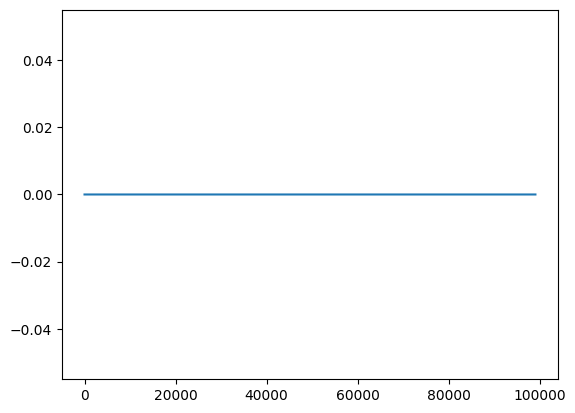

In [43]:

anomalies_concatenaded=[]

for i in range(len(anomalies)):
    if not all(anomalies[i,:]):
        anomalies_concatenaded.append(False)
    else:
        anomalies_concatenaded.append(True)

plt.plot(anomalies_concatenaded)

In [44]:
training_tensor = TimeSeriesDataset(
    StandardScaler().fit_transform(training_df), len(training_df)).__getitem__(0)

In [45]:
reconstructed_df = detector.model(training_tensor)

In [46]:
reconstructed_df = torch.t(reconstructed_df)
reconstructed_df.shape

torch.Size([99222, 16])

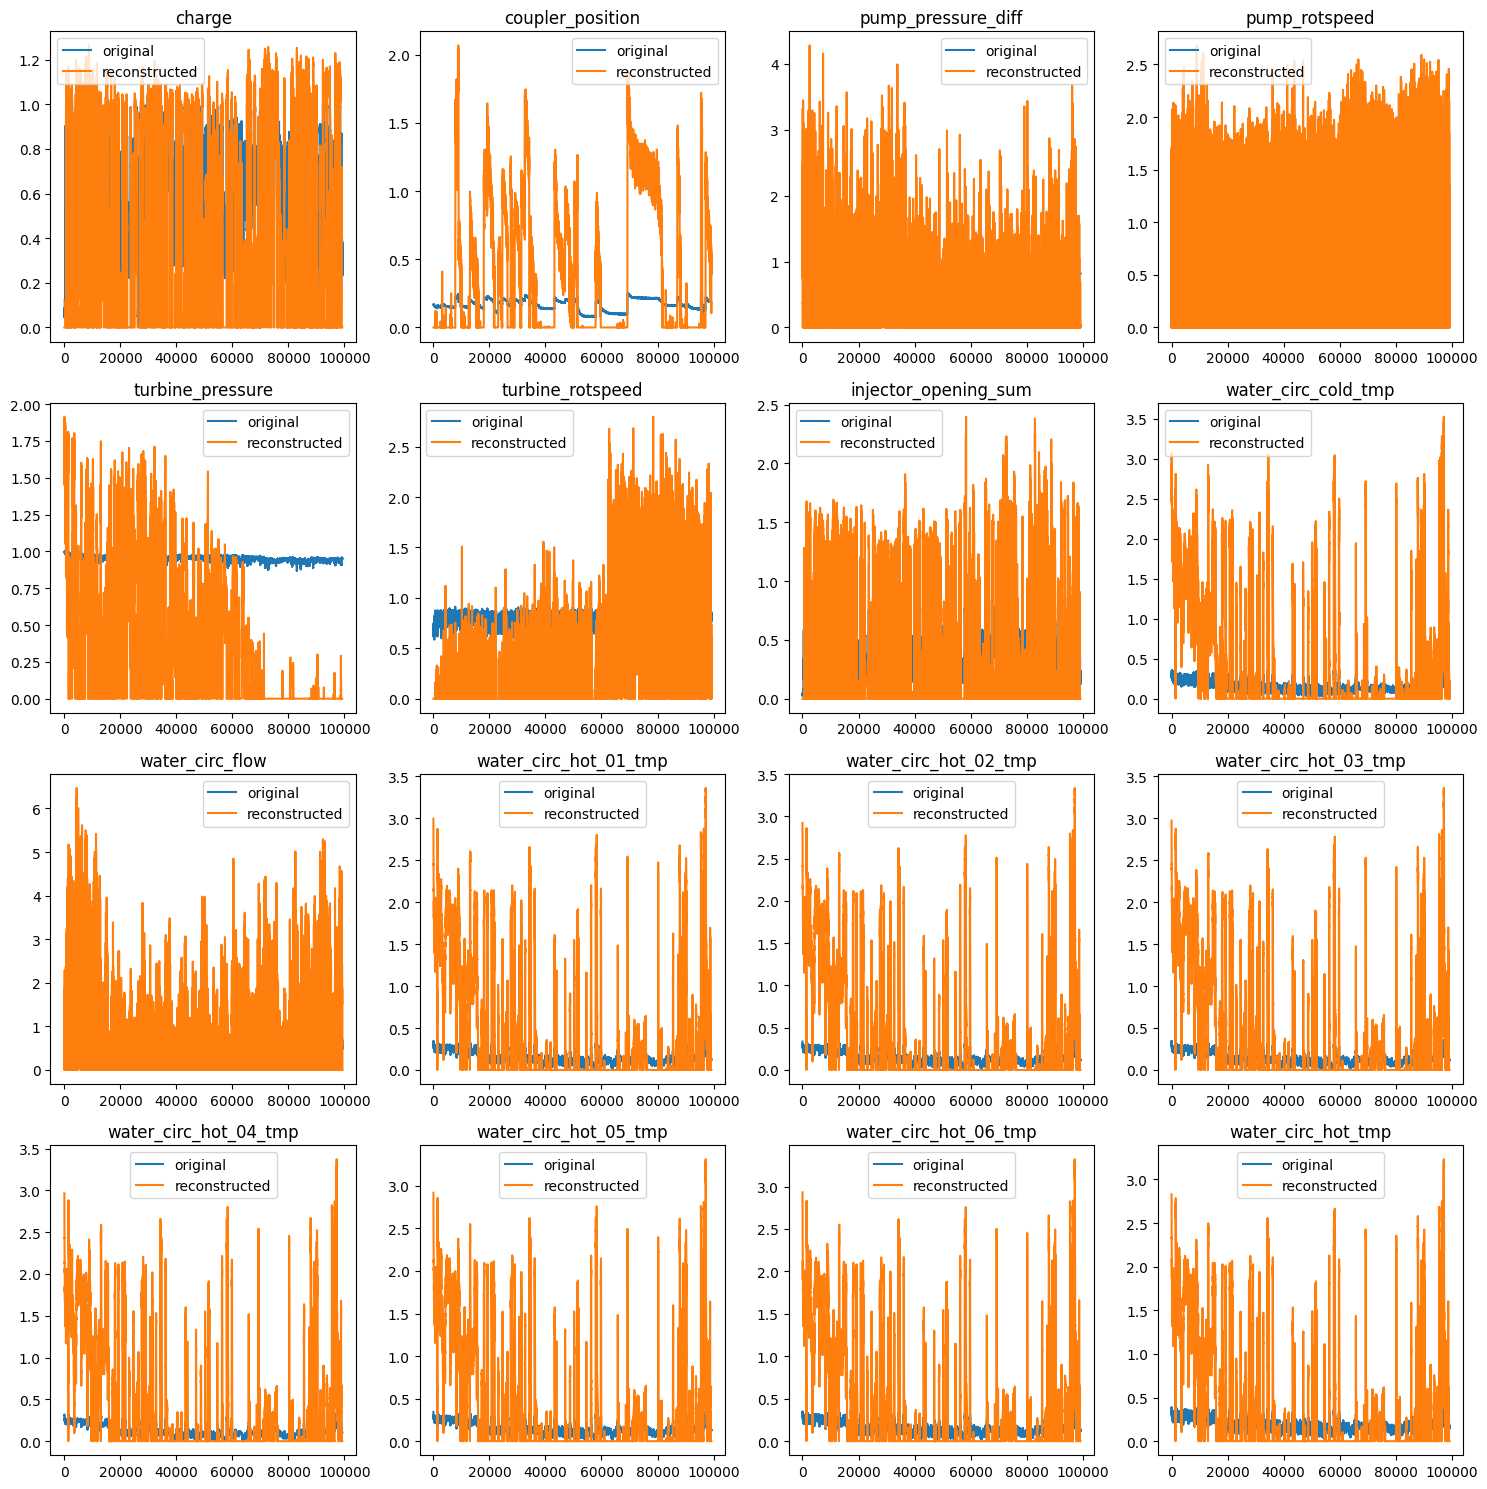

In [47]:
# Number of time series
num_series = 16

# Determine the grid size for subplots
nrows = 4  # or any other suitable value
ncols = 4  # or any other suitable value

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i in range(num_series):
    ax = axes[i]
    ax.plot(training_df.iloc[:, i].values, label='original')
    ax.plot(reconstructed_df[:, i].detach().numpy(), label="reconstructed")
    ax.set_title(training_df.columns[i])
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()